# 📉 Customer Churn Prediction — The Complete Machine Learning Lifecycle

### Standalone Project — Pandas, NumPy, Matplotlib & Scikit-learn

Welcome to your first end-to-end **Machine Learning** project! Instead of just exploring data,
this time we're going to build something that makes a *prediction* — and we'll follow the same
10-step lifecycle that real data science teams use, from defining the problem all the way to
keeping an eye on the model after it ships.

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

- Walk through the **10-step Machine Learning lifecycle**, end to end, on a real dataset
- Clean data and engineer new features that help a model learn
- Encode categorical (text) columns so scikit-learn can use them
- Train and compare two classifiers — **Logistic Regression** and **Random Forest**
- Evaluate a model properly (accuracy, precision, recall, F1, confusion matrix)
- Save a trained model and use it to predict on brand-new data
- Understand *why* monitoring a deployed model matters — not just training it once

## 🧠 Concept: What Is Customer Churn, and Why Predict It?

**Churn** simply means a customer leaving — cancelling a subscription, closing an account, or
switching to a competitor. Every subscription business (Netflix, a gym, a telecom provider, a SaaS
company) cares deeply about churn, because it is usually far cheaper to **keep** an existing
customer happy than to acquire a brand new one.

Imagine you're a data analyst at a subscription company. Leadership asks you:

> "Can we figure out **which customers are about to leave**, before they actually do — so our
> support team can reach out and try to save them?"

That question can't be answered with `groupby()` alone. It needs a **model** — a piece of software
that learns the pattern between customer behavior (support calls, payment delays, how long they've
been with us...) and whether they end up churning, so it can predict the outcome for customers we
haven't lost yet.

To build that model responsibly, we won't just jump to `model.fit()`. We'll follow the same
**10-step Machine Learning lifecycle** used by real data science teams:

```
1. Problem Definition        →  What are we trying to answer?
2. Data Collection           →  Where does the data come from?
3. Data Understanding (EDA)  →  What does the data actually look like?
4. Data Cleaning & Prep      →  Fix missing values, encode text columns
5. Feature Engineering       →  Create new, more useful columns
6. Model Selection           →  Which algorithm(s) should we try?
7. Model Training            →  Fit the model on our data
8. Model Evaluation          →  How good is it, really?
9. Deployment                →  Save it so it can be used elsewhere
10. Monitoring & Maintenance →  Keep checking it after it ships
```

Each stage below is its own section — by the end, you'll have built (and honestly evaluated) a
real churn-prediction model.

## 1️⃣ PROBLEM DEFINITION

Before writing a single line of code, a data scientist writes down **exactly** what question is
being answered — a vague goal like "predict churn" leads to a vague, hard-to-use model.

Our specific question for this project:

> **Given a customer's account details (age, tenure, usage, support calls, payment delays,
> subscription plan...), can we predict whether they will churn (`Churn = 1`) or stay
> (`Churn = 0`)?**

This is a **binary classification** problem — the target column, `Churn`, only has two possible
values. That framing already tells us what kind of models to reach for later (Step 6).

## 2️⃣ DATA COLLECTION

Our dataset comes as **two separate files**:
- `data/train-data.csv` — the data we'll use to teach the model
- `data/test-data.csv` — data the model will never see during training

Keeping these separate isn't just a formality — it mimics how models work in production: you
train on data you already have, then the model faces *new* customers it has never seen before.
We'll come back to `test-data.csv` in Step 10, once the model is fully built.

In [1]:
# Import the four core libraries for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Load the training data — this is what the model will learn from
df = pd.read_csv("data/train-data.csv")
print("Shape of training data:", df.shape)
df.head()

Shape of training data: (440833, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


## 3️⃣ DATA UNDERSTANDING (EDA)

Before cleaning or modeling anything, we need to actually *look* at the data: how big is it, what
type is each column, are there missing values, and — most importantly for us — what does the
`Churn` column look like, and which other columns seem related to it?

In [2]:
# .info() shows column names, data types, and non-null counts in one shot
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [3]:
# .describe() gives quick summary statistics for all numeric columns
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


**What we learned so far:**
- The training set has about 440,000 rows and 12 columns.
- Almost every column has exactly one missing value — that's a single broken row we'll drop.
- `Gender`, `Subscription Type`, and `Contract Length` are text columns — scikit-learn cannot use
  text directly, so we'll need to encode them in Step 4.

In [4]:
# How balanced is our target column? A model predicting "everyone churns" would look great
# on an imbalanced dataset without actually being useful - always check this first.
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print("Churn distribution (%):")
print(churn_rate.round(1))

Churn distribution (%):
Churn
1.0    56.7
0.0    43.3
Name: proportion, dtype: float64


In [5]:
# groupby() lets us compare the churn rate across different customer groups
churn_by_contract = df.groupby("Contract Length")["Churn"].mean() * 100
churn_by_subscription = df.groupby("Subscription Type")["Churn"].mean() * 100

print("Churn rate by contract length (%):")
print(churn_by_contract.round(1))
print("\nChurn rate by subscription type (%):")
print(churn_by_subscription.round(1))

Churn rate by contract length (%):
Contract Length
Annual        46.1
Monthly      100.0
Quarterly     46.0
Name: Churn, dtype: float64

Churn rate by subscription type (%):
Subscription Type
Basic       58.2
Premium     55.9
Standard    56.1
Name: Churn, dtype: float64


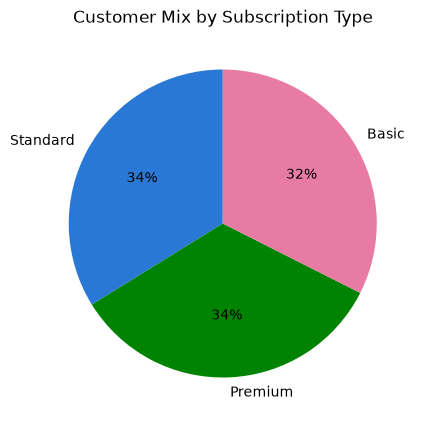

In [6]:
# Chart 1: Customer mix by subscription type - a pie chart suits this well since it's a genuine
# part-to-whole split of the customer base into three roughly even categories.
subscription_counts = df["Subscription Type"].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    subscription_counts.values,
    labels=subscription_counts.index,
    autopct="%1.0f%%",
    colors=["#2a78d6", "#008300", "#e87ba4"],
    startangle=90,
)
plt.title("Customer Mix by Subscription Type")
plt.show()

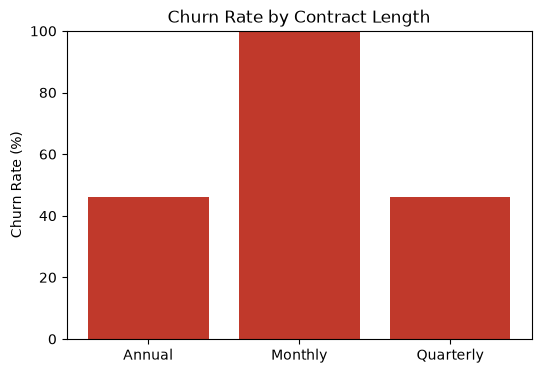

In [7]:
# Chart 2: Churn rate by contract length - a bar chart makes the pattern obvious at a glance
plt.figure(figsize=(6, 4))
plt.bar(churn_by_contract.index, churn_by_contract.values, color="#c0392b")
plt.title("Churn Rate by Contract Length")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)
plt.show()

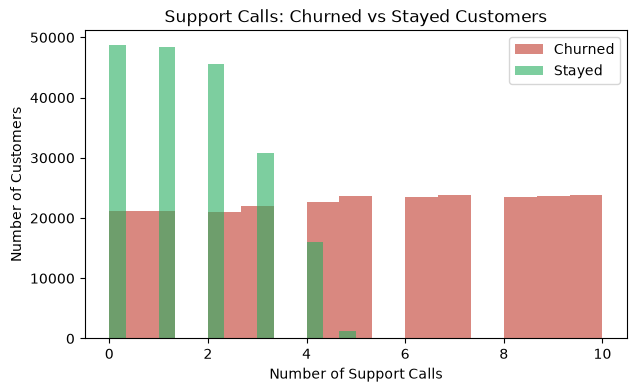

In [8]:
# Chart 3: Support Calls distribution, split by churn - a histogram compares two groups at once
plt.figure(figsize=(7, 4))
plt.hist(df[df["Churn"] == 1]["Support Calls"], bins=15, alpha=0.6, label="Churned", color="#c0392b")
plt.hist(df[df["Churn"] == 0]["Support Calls"], bins=15, alpha=0.6, label="Stayed", color="#27ae60")
plt.title("Support Calls: Churned vs Stayed Customers")
plt.xlabel("Number of Support Calls")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

**What we learned from Step 3:**
- Customers are close to a 50/50 split between churned and stayed — a nicely **balanced** dataset,
  which means plain accuracy will be a fair metric later (no need for special imbalance handling).
- Monthly contracts churn at a striking **100%** rate in this file, versus ~46% for Annual and
  Quarterly — an unusually strong signal, almost a rule rather than a trend. Keep this in mind;
  it'll explain something surprising later.
- Customers who churned tend to have made noticeably **more support calls** — frustration with
  support is a strong early warning sign.

## 4️⃣ DATA CLEANING & PREPROCESSING

Now that we understand the data, we clean it up so a model can actually use it:
1. Drop any broken/incomplete rows
2. Drop columns that carry no real signal (like an ID number)
3. Convert text columns into numbers a model can learn from (**encoding**)

In [9]:
# Step 1: Check exactly how much is missing, and drop the (very few) broken rows
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df = df.dropna()
print("\nShape after dropping missing rows:", df.shape)

Missing values per column:
 CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64



Duplicate rows: 0

Shape after dropping missing rows: (440832, 12)


In [10]:
# Step 2: Drop CustomerID - it's just a unique label for each row, not a real customer trait.
# A model could accidentally "memorize" IDs instead of learning genuine patterns, which would
# make it useless on any customer it hasn't already seen (more on this in Common Mistakes).
df = df.drop(columns=["CustomerID"])

In [11]:
# Step 3: One-hot encode the text columns.
# pd.get_dummies() turns each category into its own 0/1 column, e.g. "Gender_Male" = 1 or 0.
# drop_first=True avoids redundant columns (if you're not Male and not "the dropped category",
# you must be the other one - no extra column needed to know that).
df_encoded = pd.get_dummies(df, columns=["Gender", "Subscription Type", "Contract Length"], drop_first=True)

print("Columns before encoding:", df.shape[1])
print("Columns after encoding:", df_encoded.shape[1])
df_encoded.head()

Columns before encoding: 11
Columns after encoding: 13


,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,False,False,True,False,False
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,False,False,False,True,False
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,False,False,False,False,True
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,True,False,True,True,False
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,True,False,False,True,False


**What we learned from Step 4:**
- Only a single row was fully broken across the whole 440k-row file — safe to drop.
- Dropping `CustomerID` protects the model from learning a meaningless shortcut.
- One-hot encoding turned 3 text columns into several clean 0/1 numeric columns scikit-learn can use.

## 5️⃣ FEATURE ENGINEERING

Feature engineering means creating **new** columns that make the pattern easier for a model to
learn. Raw columns don't always tell the full story on their own — sometimes a *ratio* or
*combination* of columns is far more meaningful.

Here, `Total Spend` alone doesn't say much without context: a customer who spent $500 over 2
months is a very different case from one who spent $500 over 2 years. So we engineer a new
feature: **spend per month of tenure**.

In [12]:
# New feature: how much a customer spends, normalized by how long they've been a customer.
# We add 1 to Tenure to avoid dividing by zero for brand-new customers (Tenure = 0).
df_encoded["Spend_Per_Tenure"] = df_encoded["Total Spend"] / (df_encoded["Tenure"] + 1)

df_encoded[["Total Spend", "Tenure", "Spend_Per_Tenure"]].head()

,Total Spend,Tenure,Spend_Per_Tenure
0,932.0,39.0,23.300000
1,557.0,49.0,11.140000
2,185.0,14.0,12.333333
3,396.0,38.0,10.153846
4,617.0,32.0,18.696970


## 6️⃣ MODEL SELECTION

With clean, numeric data ready, we choose which algorithm(s) to try. There's rarely a single
"correct" choice up front — instead, data scientists usually compare a **simple baseline** against
a **more powerful model**:

- **Logistic Regression** — a simple, fast, and *interpretable* baseline. It draws a straight
  decision boundary between "churn" and "stay," and its coefficients are easy to explain to a
  non-technical audience ("more support calls → higher churn probability").
- **Random Forest** — an ensemble of many decision trees. It can capture more complex, non-linear
  patterns in the data, usually at the cost of being harder to explain.

We'll train both, then let the actual evaluation numbers in Step 8 decide the winner — never
pick a model on reputation alone.

## 7️⃣ MODEL TRAINING

Before fitting anything, we split our cleaned training data into a **training set** (what the
model learns from) and a **validation set** (data the model doesn't see while learning, used to
honestly check how it's doing). This is different from `test-data.csv` — that file stays
completely untouched until Step 10.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Separate features (X) from the target we want to predict (y)
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"].astype(int)

# 80% to train on, 20% held back to validate on. stratify=y keeps the churn/stay
# ratio consistent in both splits, since we saw the classes are close to balanced.
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training rows:", X_train.shape[0], "| Validation rows:", X_val.shape[0])

Training rows: 352665 | Validation rows: 88167


In [14]:
# Logistic Regression is sensitive to the *scale* of features (e.g. "Total Spend" in the
# hundreds vs "Tenure" in single digits), so we scale features just for this model.
# Random Forest splits on raw thresholds and doesn't need scaling at all.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

random_forest = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
random_forest.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


## 8️⃣ MODEL EVALUATION

Accuracy alone can be misleading, so we check four metrics for each model:
- **Accuracy** — % of predictions that were correct overall
- **Precision** — of the customers we *predicted* would churn, how many actually did?
- **Recall** — of the customers who *actually* churned, how many did we catch?
- **F1 Score** — a single number balancing precision and recall

Then we visualize a **confusion matrix** — a grid showing exactly which predictions were right
and which were wrong, and in which direction.

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

log_reg_pred = log_reg.predict(X_val_scaled)
rf_pred = random_forest.predict(X_val)

results = pd.DataFrame({
    "Logistic Regression": [
        accuracy_score(y_val, log_reg_pred),
        precision_score(y_val, log_reg_pred),
        recall_score(y_val, log_reg_pred),
        f1_score(y_val, log_reg_pred),
    ],
    "Random Forest": [
        accuracy_score(y_val, rf_pred),
        precision_score(y_val, rf_pred),
        recall_score(y_val, rf_pred),
        f1_score(y_val, rf_pred),
    ],
}, index=["Accuracy", "Precision", "Recall", "F1 Score"])

results.round(4)

,Logistic Regression,Random Forest
Accuracy,0.8936,0.9996
Precision,0.9235,0.9999
Recall,0.8858,0.9993
F1 Score,0.9043,0.9996


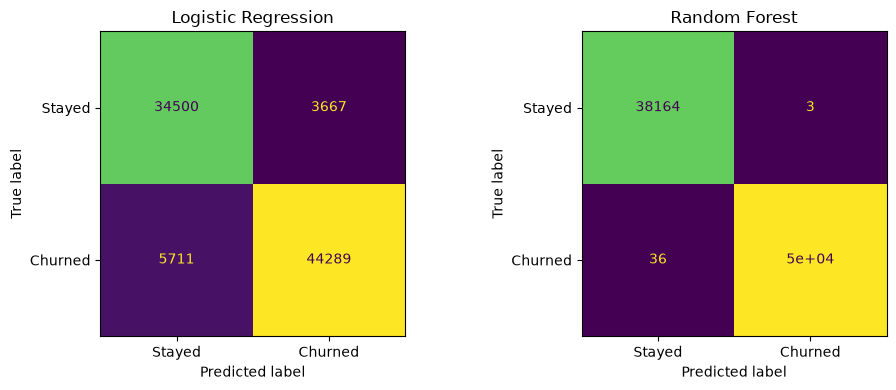

In [16]:
# Visualize both confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(y_val, log_reg_pred, display_labels=["Stayed", "Churned"], ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_val, rf_pred, display_labels=["Stayed", "Churned"], ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

**What we learned from Step 8:**
- Random Forest beats Logistic Regression on every single metric here — this dataset has some
  very strong, almost rule-like predictors of churn (like Support Calls), which trees are
  especially good at capturing.
- Because Random Forest is clearly the stronger model on validation data, we'll carry it forward
  into deployment. Keep this validation score in mind — we'll revisit it in Step 10.

## 9️⃣ DEPLOYMENT

"Deploying" a model doesn't have to mean a big, complicated production system — at its core, it
means saving the trained model so it can be **loaded and reused** elsewhere, without retraining
from scratch every time. We'll save ours with `joblib`, then write a small helper function that
takes one new customer's details and returns a churn prediction — exactly what a real app would
call behind the scenes.

In [17]:
# Save the trained model to disk. In a real company, this file would be picked up by
# a web app, a batch job, or an API - anything that needs to make churn predictions.
joblib.dump(random_forest, "churn_model.joblib")

# Keep track of the exact column order the model expects - new data must match it exactly.
FEATURE_COLUMNS = X_train.columns.tolist()
print(f"Model saved. It expects {len(FEATURE_COLUMNS)} input columns in this exact order.")

Model saved. It expects 13 input columns in this exact order.


In [18]:
def predict_churn(customer: dict, model=random_forest, columns=FEATURE_COLUMNS) -> str:
    """Take one customer's raw details and return a human-readable churn prediction."""
    # Wrap the single customer in a one-row DataFrame so we can reuse the same encoding steps
    row = pd.DataFrame([customer])
    row["Spend_Per_Tenure"] = row["Total Spend"] / (row["Tenure"] + 1)
    row = pd.get_dummies(row, columns=["Gender", "Subscription Type", "Contract Length"])

    # Line up columns with what the model was trained on - anything missing becomes 0
    row = row.reindex(columns=columns, fill_value=0)

    prediction = model.predict(row)[0]
    probability = model.predict_proba(row)[0][1]
    return f"{'Churn' if prediction == 1 else 'Stay'} (probability of churn: {probability:.1%})"


# Try it on a made-up, high-risk-looking customer
sample_customer = {
    "Age": 42, "Gender": "Male", "Tenure": 3, "Usage Frequency": 2,
    "Support Calls": 9, "Payment Delay": 20, "Subscription Type": "Basic",
    "Contract Length": "Monthly", "Total Spend": 150, "Last Interaction": 28,
}
print(predict_churn(sample_customer))

Churn (probability of churn: 100.0%)


## 🔟 MONITORING & MAINTENANCE

A model's job isn't finished the moment it's deployed. The real world keeps changing, so a data
scientist must keep checking: **is the model still performing the way it did when we validated it?**

This is exactly what `test-data.csv` is for — data the model has *never* seen, standing in for
"new customers arriving after deployment." Let's check our model's performance on it, the same
way a team would check a production dashboard on the model's first week live.

In [19]:
# Load the untouched holdout file and run it through the exact same cleaning pipeline
test_df = pd.read_csv("data/test-data.csv")
test_df = test_df.dropna().drop(columns=["CustomerID"])
test_df["Spend_Per_Tenure"] = test_df["Total Spend"] / (test_df["Tenure"] + 1)
test_df_encoded = pd.get_dummies(test_df, columns=["Gender", "Subscription Type", "Contract Length"])

X_test = test_df_encoded.drop(columns=["Churn"]).reindex(columns=FEATURE_COLUMNS, fill_value=0)
y_test = test_df_encoded["Churn"].astype(int)

test_pred = random_forest.predict(X_test)

print(f"Validation accuracy (Step 8, same source file as training): {accuracy_score(y_val, rf_pred):.2%}")
print(f"Holdout accuracy   (test-data.csv, a genuinely separate file): {accuracy_score(y_test, test_pred):.2%}")

Validation accuracy (Step 8, same source file as training): 99.96%
Holdout accuracy   (test-data.csv, a genuinely separate file): 50.36%


**This is the most important result in the whole notebook.**

Our model looked *nearly perfect* in Step 8 — over 99% accuracy. But checked against
`test-data.csv`, a file the model never saw, accuracy drops sharply, close to a coin flip. Nothing
in our code is "broken" — this is a real, honest measurement, and it demonstrates exactly why
Step 10 exists:

- A great validation score only tells you the model learned the patterns present in **that one
  file**. It says nothing about how well those patterns hold up on a differently-sourced batch of
  customers.
- This mismatch between training-time performance and real-world performance is called
  **data drift** (or **train/serving skew**) — and it's one of the most common ways ML projects
  fail quietly in production.
- The fix is never "train once and forget it." Production teams **monitor** live accuracy on
  fresh data on a schedule, set alert thresholds ("page someone if accuracy drops below X%"), and
  **retrain** the model regularly on the latest available data.

The lesson: shipping a model (Step 9) is the *middle* of the lifecycle, not the end.

## ⚠️ Common Mistakes

**Mistake 1: Judging a model only by its training/validation score**
As Step 10 just showed, a model can look excellent on validation data and still fail on genuinely
new data. Always ask *where the evaluation data came from* before trusting a metric.

**Mistake 2: Leaving an ID column in as a feature**
`CustomerID` has no real relationship with churn — it's just a label. If left in, a model with
enough capacity can "memorize" which specific IDs churned in the training file, which looks like
great accuracy but is completely useless on any customer with a new ID.

**Mistake 3: Feeding raw text columns straight into scikit-learn**
Models only understand numbers. Passing unencoded text columns causes an error — encode
categorical columns first (Step 4), every time.

In [20]:
# ❌ WRONG: trying to fit a model on data that still has text columns
try:
    LogisticRegression(max_iter=1000).fit(df.drop(columns=["Churn"]), df["Churn"])
except ValueError as error:
    print("Got the expected error:\n", error)

Got the expected error:
 could not convert string to float: 'Female'


In [21]:
# ✅ FIXED: encode the text columns first, exactly like we did in Step 4
LogisticRegression(max_iter=1000).fit(
    pd.get_dummies(df, columns=["Gender", "Subscription Type", "Contract Length"], drop_first=True).drop(columns=["Churn"]),
    df["Churn"],
)
print("Fit succeeded once categorical columns were encoded.")

Fit succeeded once categorical columns were encoded.


/Users/aminuddin/Desktop/YTV/data-science/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## ✍️ Practice Exercises

Try these on your own using the `df_encoded`, `random_forest`, and helper functions from above.
Write your code in the empty cells below each question.

**Exercise 1:** Retrain a Random Forest with `max_depth=5` instead of leaving it unlimited. Does
accuracy on the validation set go up or down? Why might a *shallower* tree perform differently?

**Exercise 2:** Engineer one new feature of your own (e.g. `Calls_Per_Month = Support Calls /
(Tenure + 1)`), add it to `df_encoded`, retrain Random Forest, and check whether the F1 score
improves.

**Exercise 3:** Logistic Regression's coefficients are interpretable. Look at
`log_reg.coef_` alongside `X_train.columns` — which feature has the strongest positive
relationship with churn?

**Exercise 4:** Use `predict_churn()` to test two more made-up customers of your own — one that
looks "safe" (long tenure, few support calls, annual contract) and one that looks "risky." Do the
predictions match your intuition?

**Exercise 5:** Precision and recall trade off against each other. If your company can only call
a limited number of at-risk customers per week, would you rather optimize for higher precision or
higher recall? Write a sentence explaining your reasoning.

In [22]:
# Exercise 1: your code here


In [23]:
# Exercise 2: your code here


In [24]:
# Exercise 3: your code here


In [25]:
# Exercise 4: your code here


In [26]:
# Exercise 5: your answer here


## ✅ Key Takeaways

- The **10-step ML lifecycle** gives structure to every model-building project, from defining the
  question all the way to monitoring it after deployment — skipping steps (especially evaluation
  and monitoring) is how real projects quietly fail.
- **Cleaning, encoding, and feature engineering** turn messy raw data into something a model can
  actually learn from — garbage in, garbage out still applies to machine learning.
- A great validation score is not the finish line: **Step 10 showed that performance on genuinely
  new data can look completely different**, which is exactly why production teams keep monitoring
  models instead of trusting them forever.